#### Data Visualization With Seaborn
Seaborn is a Python visualization library based on Matplotlib that provides a high-level interface for drawing attractive and informative statistical graphics. Seaborn helps in creating complex visualizations with just a few lines of code. In this lesson, we will cover the basics of Seaborn, including creating various types of plots and customizing them. 

In [1]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import seaborn as sns

In [4]:
### Basic Plotting With Seaborn
tips=sns.load_dataset('tips') #built-in “tips” dataset from the Seaborn library and stores it as a "Pandas DataFrame" named tips
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


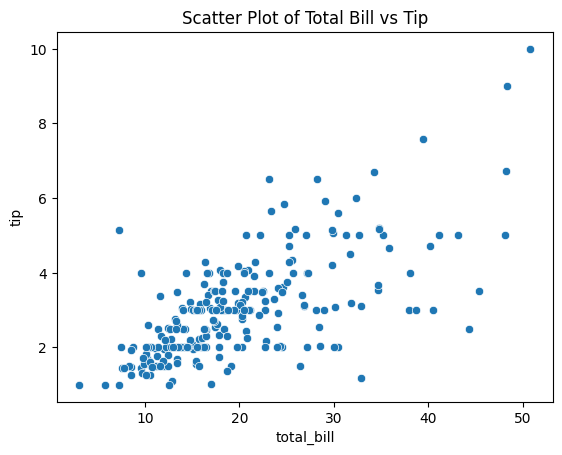

In [5]:
##create a scatter plot
import matplotlib.pyplot as plt
#total_bill and tip are column names , also you can pass as tips['total_bill'](data parameter not passed in this way)
sns.scatterplot(x='total_bill',y='tip',data=tips) #data is required when using column names, but not required when passing actual values or Series directly.
plt.title("Scatter Plot of Total Bill vs Tip")
plt.show()

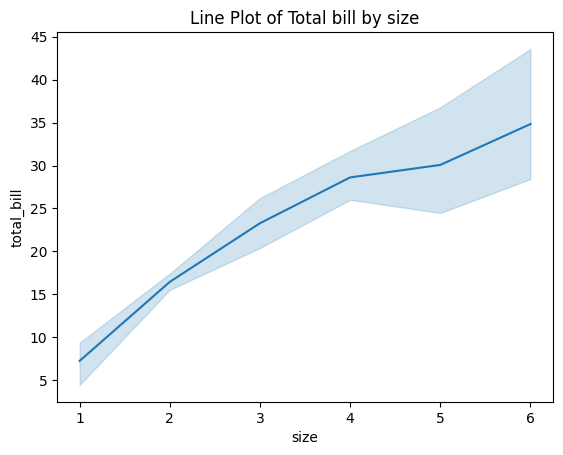

In [6]:
## Line Plot

sns.lineplot(x='size',y='total_bill',data=tips)
plt.title("Line Plot of Total bill by size")
plt.show()

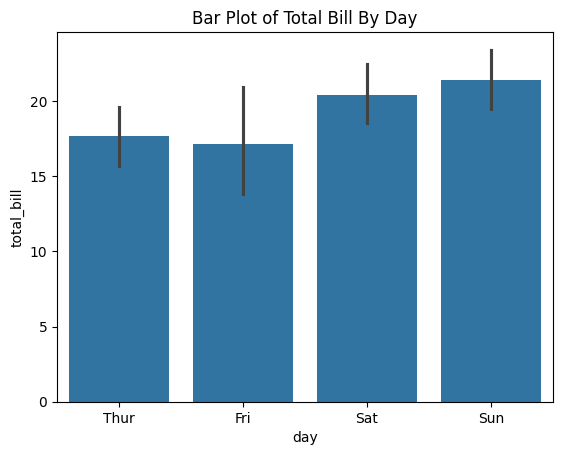

In [ ]:
## Categorical Plots
## BAr Plot
#Internally, Seaborn does this: For each day->collects all total_bill values,computes mean,plots that value as bar height
sns.barplot(x='day',y='total_bill',data=tips) #For each day (Thur, Fri, Sat, Sun), plot the average total_bill
plt.title('Bar Plot of Total Bill By Day')
plt.show()
#To remove this black line(black line on each bar is an error bar,shows confidence interval), pass as below :->
#sns.barplot(x='day', y='total_bill', data=tips, ci=None)

<Axes: xlabel='day', ylabel='total_bill'>

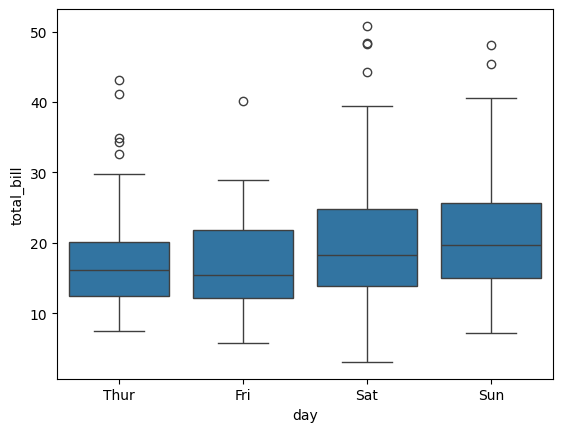

In [ ]:
## Box Plot
sns.boxplot(x="day",y='total_bill',data=tips)
#circles -> outlier
#Box height (IQR = Q3 − Q1) → spread of most data
#Represented in 0,25(Q1),50,75(Q3),100 percentile form. Horizontal black line shows the percentile.

<Axes: xlabel='day', ylabel='total_bill'>

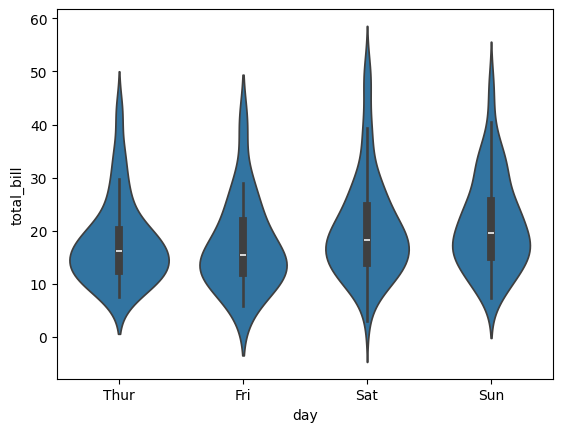

In [9]:
## Violin Plot

sns.violinplot(x='day',y='total_bill',data=tips)
# Width of the violin → where data is more concentrated(wider = more customers paid around that amount)
# Middle white dot/line → median total bill , Thick central bar → interquartile range (Q1 to Q3)

# blue region denotes the density distribution of the data.Wider blue area → more data points at that value

<Axes: xlabel='total_bill', ylabel='Count'>

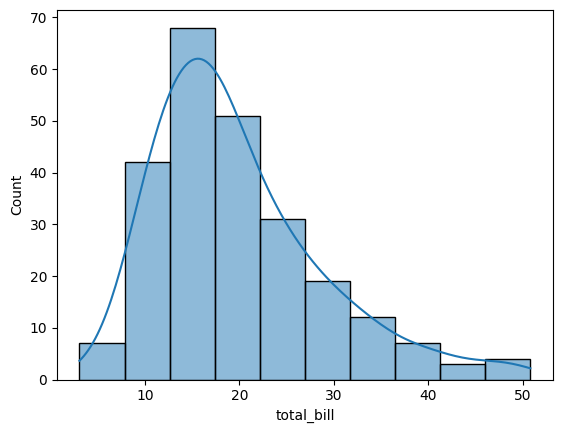

In [10]:
### Histograms
sns.histplot(tips['total_bill'],bins=10,kde=True) #KDE draws a smooth curve that shows the overall distribution pattern of the data.It tells where values are concentrated, not the average.

<Axes: xlabel='total_bill', ylabel='Density'>

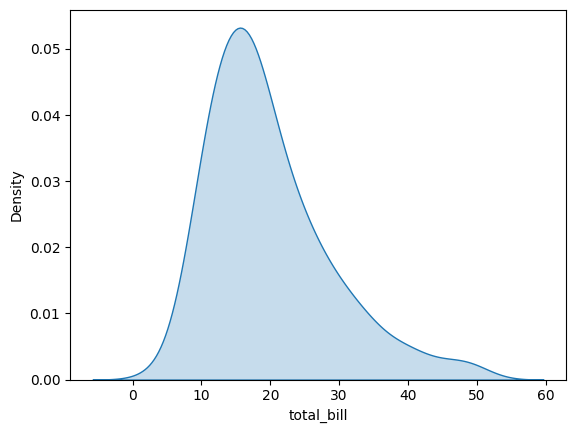

In [12]:
## KDE Plot
sns.kdeplot(tips['total_bill'],fill=True) #fill -> shade the region below curve

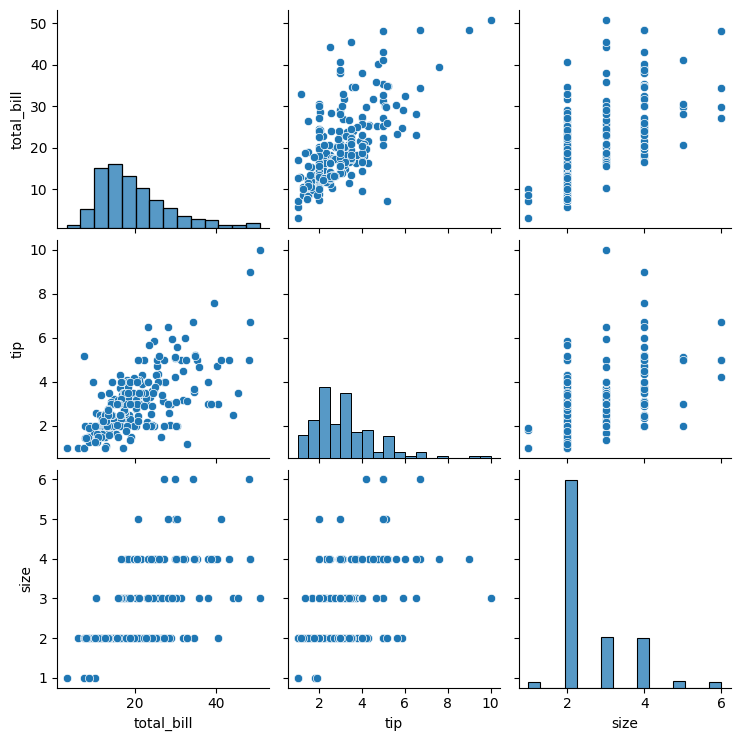

In [ ]:
# Pairplot ->Visualize relationships and distributions between multiple variables at once
sns.pairplot(tips) #for this, you specefically need numerical values
#For categorial variable(gender,day), it is not taken under consideration

In [13]:
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [14]:
## HEatmap
corr=tips[['total_bill','tip','size']].corr() #.corr() checks how each column is related to the others.
#+1 → strong positive relation,−1 → strong negative relation,0 -> no relation
# total_bill & tip → positive correlation(higher bill → higher tip),size & tip → weaker but still related
corr

,total_bill,tip,size
total_bill,1.000000,0.675734,0.598315
tip,0.675734,1.000000,0.489299
size,0.598315,0.489299,1.000000


<Axes: >

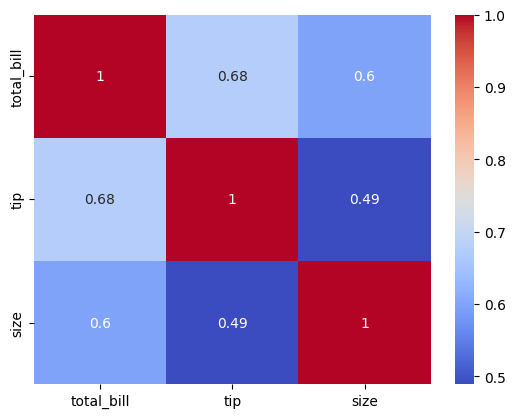

In [15]:
sns.heatmap(corr,annot=True,cmap='coolwarm') 
# corr → the correlation matrix data to be visualized, annot=True → displays correlation values inside each cell

In [16]:
import pandas as pd
sales_df=pd.read_csv('sales_data.csv')
sales_df.head()

,Transaction ID,Date,Product Category,Product Name,Units Sold,Unit Price,Total Revenue,Region,Payment Method
0,10001,2024-01-01,Electronics,iPhone 14 Pro,2,999.99,1999.98,North America,Credit Card
1,10002,2024-01-02,Home Appliances,Dyson V11 Vacuum,1,499.99,499.99,Europe,PayPal
2,10003,2024-01-03,Clothing,Levi's 501 Jeans,3,69.99,209.97,Asia,Debit Card
3,10004,2024-01-04,Books,The Da Vinci Code,4,15.99,63.96,North America,Credit Card
4,10005,2024-01-05,Beauty Products,Neutrogena Skincare Set,1,89.99,89.99,Europe,PayPal


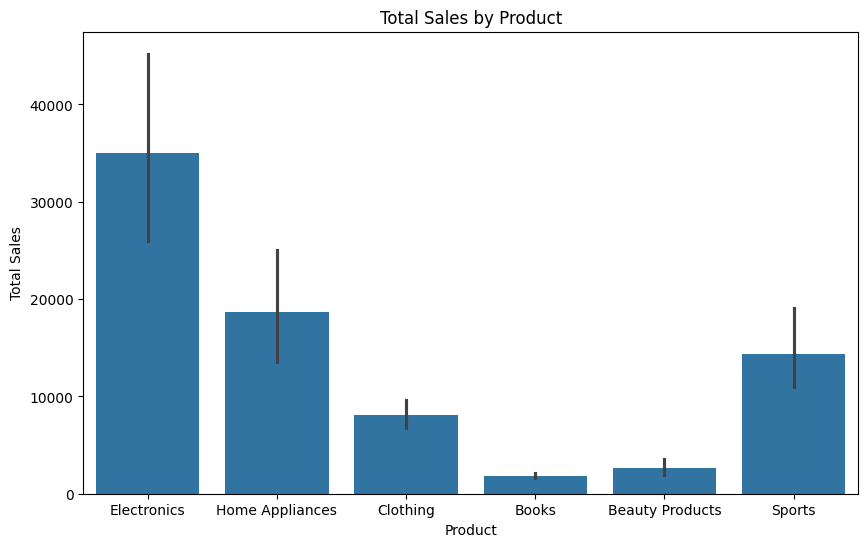

In [ ]:
## Plot total sales by product
plt.figure(figsize=(10,6))
sns.barplot(x='Product Category',y="Total Revenue",data=sales_df,estimator=sum) #Inside estimator, you can put the aggregator functions(make it simplier than matplotlib)
plt.title('Total Sales by Product')
plt.xlabel('Product')
plt.ylabel('Total Sales')
plt.show()

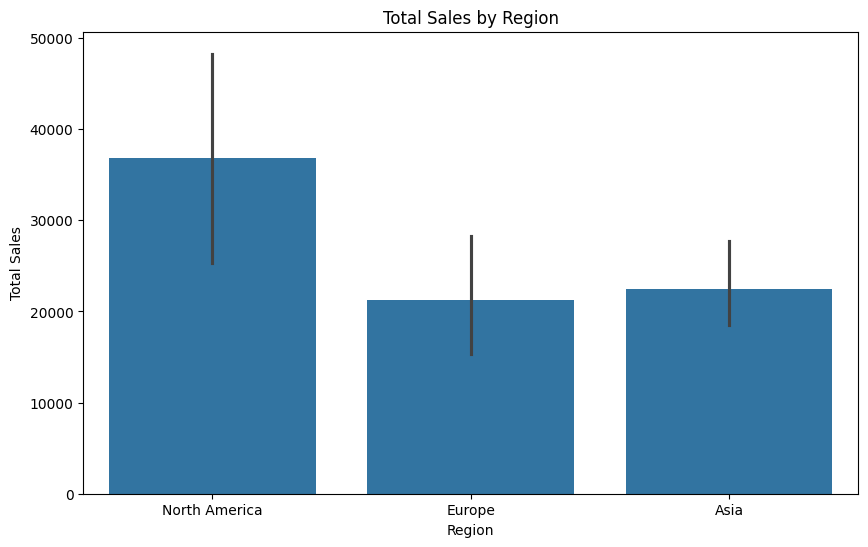

In [17]:
## Plot total sales by Region
plt.figure(figsize=(10,6))
sns.barplot(x='Region',y="Total Revenue",data=sales_df,estimator=sum)
plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.show()